# Slater-determinant walker entanglement in H$_8$ AFQMC and Hubbard CPMC

This notebook runs phaseless AFQMC for a linear H$_8$ chain with a UHF trial
and unrestricted walkers. Walker populations are saved at fixed imaginary-time
intervals and analyzed as pure fermionic Gaussian states.

Trot represents this UHF calculation in the alpha molecular-orbital basis.
Entanglement in that canonical basis would not correspond to a spatial cut.
Before analysis, every walker is therefore transformed to ordered symmetric
(Löwdin) orthogonalized atomic orbitals, one per H site.

For one spin component with orthonormal walker orbitals $Q_\sigma$, the
correlation matrix is

$$
C_\sigma = Q_\sigma Q_\sigma^\dagger.
$$

At a spatial cut $A$, let $\nu_{\sigma k}$ be the eigenvalues of the restricted
matrix $(C_\sigma)_A$. The Slater-determinant entanglement entropy is

$$
S_A = -\sum_{\sigma k}
\left[\nu_{\sigma k}\log\nu_{\sigma k}
+(1-\nu_{\sigma k})\log(1-\nu_{\sigma k})\right].
$$

The reported effective dimension $D_{\rm eff}=\exp(S_A)$ is a useful scale,
but it is not the MPS bond dimension required at a specified discarded weight.


In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
import csv
import json

import numpy as np

from trot import config

config.configure_once()

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.experimental import io_callback
from pyscf import fci, gto, scf

from trot import driver
from trot.core.system import System
from trot.ham.hubbard import HamHubbard
from trot.meas.ghf import make_ghf_meas_ops_hubbard
from trot.prop.blocks import (
    BlockObs,
    block,
    dump_prop_state_npz,
    load_prop_state_npz,
)
from trot.prop.cpmc import make_prop_ops as make_cpmc_prop_ops
from trot.prop.types import PropState, QmcParams
from trot.setup import setup
from trot.trial.ghf import GhfTrial, make_ghf_trial_ops
from trot.walkers import stochastic_reconfiguration

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


## Configuration

The defaults below are a meaningful local AFQMC pilot rather than a smoke test:
200 walkers, 50 propagation steps per block, 50 equilibration blocks, 500
production blocks, and $\Delta\tau=0.005\ E_h^{-1}$. A snapshot is saved every
10 blocks. Since Trot performs stochastic reconfiguration at the end of every
block, saved walkers have equal weights and their multiplicities encode the
pre-resampling importance weights.


In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    n_h: int = 8
    bond_length_bohr: float = 3.0
    basis: str = "sto-6g"
    charge: int = 0
    spin: int = 0

    dt: float = 0.005
    n_walkers: int = 200
    n_prop_steps: int = 50
    n_eql_blocks: int = 50
    n_blocks: int = 500
    snapshot_every_blocks: int = 10
    n_chunks: int = 1
    seed: int = 731_008

    scf_conv_tol: float = 1.0e-10
    scf_max_cycle: int = 200
    scf_level_shift: float = 0.2

    hubbard_t: float = 1.0
    hubbard_u: float = 6.0
    hubbard_seed: int = 731_009
    hubbard_uhf_mixing: float = 0.5
    hubbard_uhf_tol: float = 1.0e-12
    hubbard_uhf_max_cycles: int = 500


CFG = ExperimentConfig()


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "trot").is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the Trot repository above {start}")


REPO_ROOT = find_repo_root(Path.cwd())
RUN_TAG = f"h{CFG.n_h}_r{CFG.bond_length_bohr:g}_{CFG.basis}_" f"uhf_uw_seed{CFG.seed}"
OUTPUT_DIR = REPO_ROOT / "runs" / "sd_to_mps_data" / RUN_TAG
SNAPSHOT_DIR = OUTPUT_DIR / "walkers"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)

with (OUTPUT_DIR / "config.json").open("w") as handle:
    json.dump(asdict(CFG), handle, indent=2)

print("Repository root:", REPO_ROOT)
print("Output directory:", OUTPUT_DIR)
print(json.dumps(asdict(CFG), indent=2))

Repository root: /Users/fnappi/trot_mps
Output directory: /Users/fnappi/trot_mps/runs/sd_to_mps_data/h8_r3_sto-6g_uhf_uw_seed731008
{
  "n_h": 8,
  "bond_length_bohr": 3.0,
  "basis": "sto-6g",
  "charge": 0,
  "spin": 0,
  "dt": 0.005,
  "n_walkers": 200,
  "n_prop_steps": 50,
  "n_eql_blocks": 50,
  "n_blocks": 500,
  "snapshot_every_blocks": 10,
  "n_chunks": 1,
  "seed": 731008,
  "scf_conv_tol": 1e-10,
  "scf_max_cycle": 200,
  "scf_level_shift": 0.2,
  "hubbard_t": 1.0,
  "hubbard_u": 6.0,
  "hubbard_seed": 731009,
  "hubbard_uhf_mixing": 0.5,
  "hubbard_uhf_tol": 1e-12,
  "hubbard_uhf_max_cycles": 500
}


## H$_8$ UHF reference

A Néel-like initial density is constructed in ordered Löwdin orbitals. This
encourages the stretched chain to converge to the antiferromagnetic broken-
symmetry UHF solution rather than returning to RHF.


In [3]:
def make_h_chain(cfg: ExperimentConfig) -> gto.Mole:
    atoms = [("H", (0.0, 0.0, i * cfg.bond_length_bohr)) for i in range(cfg.n_h)]
    return gto.M(
        atom=atoms,
        basis=cfg.basis,
        unit="Bohr",
        charge=cfg.charge,
        spin=cfg.spin,
        verbose=3,
    )


def symmetric_orthogonalizer(overlap: np.ndarray, cutoff: float = 1.0e-12) -> np.ndarray:
    overlap_h = 0.5 * (overlap + overlap.T.conj())
    eigenvalues, eigenvectors = np.linalg.eigh(overlap_h)
    if np.min(eigenvalues) <= cutoff:
        raise np.linalg.LinAlgError(
            "AO overlap matrix is not numerically positive definite: "
            f"min eigenvalue={np.min(eigenvalues):.3e}"
        )
    return (eigenvectors * eigenvalues[None, :] ** -0.5) @ eigenvectors.T.conj()


mol = make_h_chain(CFG)
overlap_ao = np.asarray(mol.intor_symmetric("int1e_ovlp"))
local_orbitals_ao = symmetric_orthogonalizer(overlap_ao)

np.testing.assert_allclose(
    local_orbitals_ao.T.conj() @ overlap_ao @ local_orbitals_ao,
    np.eye(CFG.n_h),
    atol=1.0e-10,
)

n_alpha, n_beta = mol.nelec
if mol.nao_nr() != CFG.n_h:
    raise ValueError(
        "This experiment assumes one spatial AO per H site; "
        f"received nao={mol.nao_nr()} for n_h={CFG.n_h}."
    )

occ_alpha = np.arange(0, CFG.n_h, 2)[:n_alpha]
occ_beta = np.arange(1, CFG.n_h, 2)[:n_beta]
c_occ_alpha = local_orbitals_ao[:, occ_alpha]
c_occ_beta = local_orbitals_ao[:, occ_beta]
dm_neel = (
    c_occ_alpha @ c_occ_alpha.T.conj(),
    c_occ_beta @ c_occ_beta.T.conj(),
)

mf = scf.UHF(mol)
mf.conv_tol = CFG.scf_conv_tol
mf.max_cycle = CFG.scf_max_cycle
mf.level_shift = CFG.scf_level_shift
mf.kernel(dm0=dm_neel)
if not mf.converged:
    print("Direct UHF did not converge; continuing with the second-order solver.")
    mf = mf.newton()
    mf.conv_tol = CFG.scf_conv_tol
    mf.max_cycle = CFG.scf_max_cycle
    mf.kernel(dm0=mf.make_rdm1())
if not mf.converged:
    raise RuntimeError("H8 UHF reference did not converge")

s2, multiplicity = mf.spin_square()
print(f"UHF energy       = {mf.e_tot:.12f} Eh")
print(f"<S^2>            = {s2:.8f}")
print(f"spin multiplicity= {multiplicity:.8f}")

converged SCF energy = -3.88161274459339  <S^2> = 2.7282847  2S+1 = 3.4515415
UHF energy       = -3.881612744593 Eh
<S^2>            = 2.72828467
spin multiplicity= 3.45154149


Trot stages UHF Hamiltonians and walkers in the full alpha-MO basis. If
$C_\alpha$ contains the alpha MOs and $C_{\rm loc}$ contains the ordered local
orbitals, then

$$
C_{\rm loc}=C_\alpha U,\qquad
U=C_\alpha^\dagger S C_{\rm loc},
$$

and a staged walker transforms as $W_{\rm loc}=U^\dagger W_\alpha$.


In [4]:
alpha_mos_ao = np.asarray(mf.mo_coeff[0])
alpha_mo_to_local = alpha_mos_ao.T.conj() @ overlap_ao @ local_orbitals_ao

np.testing.assert_allclose(
    alpha_mo_to_local.T.conj() @ alpha_mo_to_local,
    np.eye(CFG.n_h),
    atol=1.0e-9,
)
np.testing.assert_allclose(
    alpha_mos_ao @ alpha_mo_to_local,
    local_orbitals_ao,
    atol=1.0e-9,
)
print("Validated unitary alpha-MO -> ordered local-orbital transformation.")

Validated unitary alpha-MO -> ordered local-orbital transformation.


## Fixed-interval walker logger

The helper below wraps Trot's standard block without changing propagation. It
saves the post-resampling `PropState` every `snapshot_every_blocks` blocks.
Block numbers count equilibration and production continuously.


In [5]:
def make_interval_block_state_logger(
    directory: Path,
    *,
    every_n_blocks: int,
):
    if every_n_blocks <= 0:
        raise ValueError("every_n_blocks must be positive")

    directory = directory.resolve()
    directory.mkdir(parents=True, exist_ok=True)
    callback_count = 0
    result_spec = jax.ShapeDtypeStruct((), jnp.int32)

    def write_if_due(state: PropState) -> np.int32:
        nonlocal callback_count
        callback_count += 1
        if callback_count % every_n_blocks == 0:
            path = directory / f"block_state_{callback_count:05d}.npz"
            dump_prop_state_npz(state, path, compressed=True)
        return np.int32(0)

    def logging_block(
        state: PropState,
        *,
        sys,
        params,
        ham_data,
        trial_data,
        trial_ops,
        meas_ops,
        meas_ctx,
        prop_ops,
        prop_ctx,
        sr_fn=stochastic_reconfiguration,
        observable_names=(),
    ) -> tuple[PropState, BlockObs]:
        state, observations = block(
            state,
            sys=sys,
            params=params,
            ham_data=ham_data,
            trial_data=trial_data,
            trial_ops=trial_ops,
            meas_ops=meas_ops,
            meas_ctx=meas_ctx,
            prop_ops=prop_ops,
            prop_ctx=prop_ctx,
            sr_fn=sr_fn,
            observable_names=observable_names,
        )
        _ = io_callback(write_if_due, result_spec, state, ordered=True)
        return state, observations

    return logging_block


expected_snapshot_blocks = np.arange(
    CFG.snapshot_every_blocks,
    CFG.n_eql_blocks + CFG.n_blocks + 1,
    CFG.snapshot_every_blocks,
    dtype=int,
)
print("Snapshot blocks:", expected_snapshot_blocks)

Snapshot blocks: [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530 540
 550]


## Phaseless AFQMC

Unrestricted walkers are used deliberately: they preserve the distinct alpha
and beta UHF orbitals and allow the two spin contributions to the Slater-
determinant entanglement to be examined separately.


In [6]:
qmc_params = QmcParams(
    dt=CFG.dt,
    n_walkers=CFG.n_walkers,
    n_prop_steps=CFG.n_prop_steps,
    n_eql_blocks=CFG.n_eql_blocks,
    n_blocks=CFG.n_blocks,
    n_chunks=CFG.n_chunks,
    seed=CFG.seed,
    error_method="gamma",
)

snapshot_logger = make_interval_block_state_logger(
    SNAPSHOT_DIR,
    every_n_blocks=CFG.snapshot_every_blocks,
)
job = setup(
    mf,
    walker_kind="unrestricted",
    mixed_precision=False,
    params=qmc_params,
    block_fn=snapshot_logger,
)

result = job.kernel()
print(
    f"AFQMC energy = {float(result.mean_energy):.10f} +/- " f"{float(result.stderr_energy):.3e} Eh"
)

afqmc_summary = {
    "uhf_energy": float(mf.e_tot),
    "uhf_s2": float(s2),
    "mean_energy": float(result.mean_energy),
    "stderr_energy": float(result.stderr_energy),
    "error_method": result.error_method,
    "error_reliable": bool(result.error_reliable),
    "gamma_window": result.gamma_window,
    "gamma_window_found": bool(result.gamma_window_found),
    "tau_int": result.tau_int,
    "effective_sample_size": result.effective_sample_size,
    "gamma_warnings": list(result.gamma_warnings),
    "blocking_B_star": result.blocking_B_star,
    "blocking_plateau_found": bool(result.blocking_plateau_found),
    "blocking_selection_reason": result.blocking_selection_reason,
}
with (OUTPUT_DIR / "afqmc_summary.json").open("w") as handle:
    json.dump(afqmc_summary, handle, indent=2)
np.savez_compressed(
    OUTPUT_DIR / "afqmc_blocks.npz",
    energy=np.asarray(jax.device_get(result.block_energies)),
    weight=np.asarray(jax.device_get(result.block_weights)),
)
print("Saved", OUTPUT_DIR / "afqmc_summary.json")
print("Saved", OUTPUT_DIR / "afqmc_blocks.npz")
if not result.error_reliable:
    print(
        "Energy warning: the configured error analysis is not reliable for this trajectory. "
        "The present run is used for walker-entanglement diagnostics, not as a final energy benchmark."
    )

TypeError: QmcParams.__init__() got an unexpected keyword argument 'error_method'

## Correlation-matrix entanglement analysis

The analysis computes the entropy at every spatial cut. The center-cut value
addresses the original question, while the maximum across cuts is the relevant
lower-bound scale for a full MPS representation.


In [ ]:
def orthonormal_columns(matrix: np.ndarray) -> np.ndarray:
    q, r = np.linalg.qr(matrix, mode="reduced")
    diagonal = np.diag(r)
    phases = diagonal / np.where(np.abs(diagonal) == 0.0, 1.0, np.abs(diagonal))
    return q * phases.conj()[None, :]


def binary_entropy(occupations: np.ndarray, tolerance: float = 1.0e-14) -> float:
    occupations = np.clip(np.real(occupations), 0.0, 1.0)
    active = (occupations > tolerance) & (occupations < 1.0 - tolerance)
    values = occupations[active]
    return float(-np.sum(values * np.log(values) + (1.0 - values) * np.log1p(-values)))


def spin_cut_spectrum(walker_local: np.ndarray, cut: int) -> np.ndarray:
    q = orthonormal_columns(walker_local)
    q_left = q[:cut]
    correlation_left = q_left @ q_left.T.conj()
    correlation_left = 0.5 * (correlation_left + correlation_left.T.conj())
    return np.clip(np.linalg.eigvalsh(correlation_left), 0.0, 1.0)


def walker_entropy_profile(
    walker_alpha: np.ndarray,
    walker_beta: np.ndarray,
    mo_to_local: np.ndarray,
) -> tuple[np.ndarray, list[tuple[np.ndarray, np.ndarray]]]:
    walker_alpha_local = mo_to_local.T.conj() @ walker_alpha
    walker_beta_local = mo_to_local.T.conj() @ walker_beta

    entropies = []
    spectra = []
    for cut in range(1, mo_to_local.shape[0]):
        nu_alpha = spin_cut_spectrum(walker_alpha_local, cut)
        nu_beta = spin_cut_spectrum(walker_beta_local, cut)
        entropies.append(binary_entropy(nu_alpha) + binary_entropy(nu_beta))
        spectra.append((nu_alpha, nu_beta))
    return np.asarray(entropies), spectra


def weighted_quantiles(
    values: np.ndarray,
    weights: np.ndarray,
    probabilities: np.ndarray,
) -> np.ndarray:
    order = np.argsort(values)
    values_sorted = values[order]
    weights_sorted = np.abs(weights[order])
    if np.sum(weights_sorted) == 0.0:
        return np.full_like(probabilities, np.nan, dtype=float)
    cumulative = (np.cumsum(weights_sorted) - 0.5 * weights_sorted) / np.sum(weights_sorted)
    return np.interp(probabilities, cumulative, values_sorted)


snapshot_files = [
    SNAPSHOT_DIR / f"block_state_{block_number:05d}.npz"
    for block_number in expected_snapshot_blocks
]
missing_files = [path for path in snapshot_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"Missing expected walker snapshots: {missing_files}")

center_cut = CFG.n_h // 2
n_snapshots = len(snapshot_files)
n_cuts = CFG.n_h - 1
entropy_by_cut = np.empty((n_snapshots, CFG.n_walkers, n_cuts), dtype=float)
snapshot_weights = np.empty((n_snapshots, CFG.n_walkers), dtype=float)
center_nu_alpha = np.empty((n_snapshots, CFG.n_walkers, center_cut), dtype=float)
center_nu_beta = np.empty((n_snapshots, CFG.n_walkers, center_cut), dtype=float)

for snapshot_index, path in enumerate(snapshot_files):
    state = load_prop_state_npz(path)
    walkers_alpha, walkers_beta = jax.device_get(state.walkers)
    weights = np.asarray(jax.device_get(state.weights), dtype=float)
    snapshot_weights[snapshot_index] = weights

    for walker_index, (walker_alpha, walker_beta) in enumerate(
        zip(np.asarray(walkers_alpha), np.asarray(walkers_beta), strict=True)
    ):
        profile, spectra = walker_entropy_profile(
            walker_alpha,
            walker_beta,
            alpha_mo_to_local,
        )
        entropy_by_cut[snapshot_index, walker_index] = profile
        nu_alpha, nu_beta = spectra[center_cut - 1]
        center_nu_alpha[snapshot_index, walker_index] = nu_alpha
        center_nu_beta[snapshot_index, walker_index] = nu_beta

center_entropy = entropy_by_cut[:, :, center_cut - 1]
maximum_entropy = np.max(entropy_by_cut, axis=-1)
quantile_probabilities = np.asarray([0.10, 0.50, 0.90, 0.95, 0.99])

center_mean = np.empty(n_snapshots)
center_quantiles = np.empty((n_snapshots, len(quantile_probabilities)))
maximum_mean = np.empty(n_snapshots)
maximum_quantiles = np.empty((n_snapshots, len(quantile_probabilities)))

for snapshot_index in range(n_snapshots):
    weights = np.abs(snapshot_weights[snapshot_index])
    center_mean[snapshot_index] = np.average(center_entropy[snapshot_index], weights=weights)
    maximum_mean[snapshot_index] = np.average(maximum_entropy[snapshot_index], weights=weights)
    center_quantiles[snapshot_index] = weighted_quantiles(
        center_entropy[snapshot_index], weights, quantile_probabilities
    )
    maximum_quantiles[snapshot_index] = weighted_quantiles(
        maximum_entropy[snapshot_index], weights, quantile_probabilities
    )

imaginary_time = expected_snapshot_blocks * CFG.n_prop_steps * CFG.dt

np.savez_compressed(
    OUTPUT_DIR / "walker_entanglement.npz",
    block=expected_snapshot_blocks,
    imaginary_time=imaginary_time,
    entropy_by_cut=entropy_by_cut,
    center_entropy=center_entropy,
    maximum_entropy=maximum_entropy,
    snapshot_weights=snapshot_weights,
    center_nu_alpha=center_nu_alpha,
    center_nu_beta=center_nu_beta,
    quantile_probabilities=quantile_probabilities,
    center_mean=center_mean,
    center_quantiles=center_quantiles,
    maximum_mean=maximum_mean,
    maximum_quantiles=maximum_quantiles,
)

summary_rows = []
for index, block_number in enumerate(expected_snapshot_blocks):
    row = {
        "block": int(block_number),
        "phase": "equilibration" if block_number <= CFG.n_eql_blocks else "production",
        "imaginary_time": float(imaginary_time[index]),
        "center_mean_entropy": float(center_mean[index]),
        "center_effective_dimension": float(np.exp(center_mean[index])),
        "maximum_mean_entropy": float(maximum_mean[index]),
        "maximum_effective_dimension": float(np.exp(maximum_mean[index])),
    }
    for probability, value in zip(quantile_probabilities, center_quantiles[index], strict=True):
        row[f"center_q{int(round(100 * probability)):02d}"] = float(value)
    for probability, value in zip(quantile_probabilities, maximum_quantiles[index], strict=True):
        row[f"maximum_q{int(round(100 * probability)):02d}"] = float(value)
    summary_rows.append(row)

with (OUTPUT_DIR / "entropy_summary.csv").open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0]))
    writer.writeheader()
    writer.writerows(summary_rows)

print("Saved", OUTPUT_DIR / "walker_entanglement.npz")
print("Saved", OUTPUT_DIR / "entropy_summary.csv")
print("Final snapshot summary:")
for key, value in summary_rows[-1].items():
    print(f"  {key:>30s}: {value}")

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/h8_r3_sto-6g_uhf_uw_seed731008/walker_entanglement.npz
Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/h8_r3_sto-6g_uhf_uw_seed731008/entropy_summary.csv
Final snapshot summary:
                           block: 550
                           phase: production
                  imaginary_time: 137.5
             center_mean_entropy: 1.227287063156577
      center_effective_dimension: 3.41196053542285
            maximum_mean_entropy: 1.6718816371777485
     maximum_effective_dimension: 5.322172779524216
                      center_q10: 0.4992050084994507
                      center_q50: 1.1270218196916053
                      center_q90: 2.060155295872048
                      center_q95: 2.2647597519159954
                      center_q99: 2.4753798383410546
                     maximum_q10: 1.417689173696883
                     maximum_q50: 1.5317454454843857
                     maximum_q90: 2.1727437358900197
     

## Entanglement growth


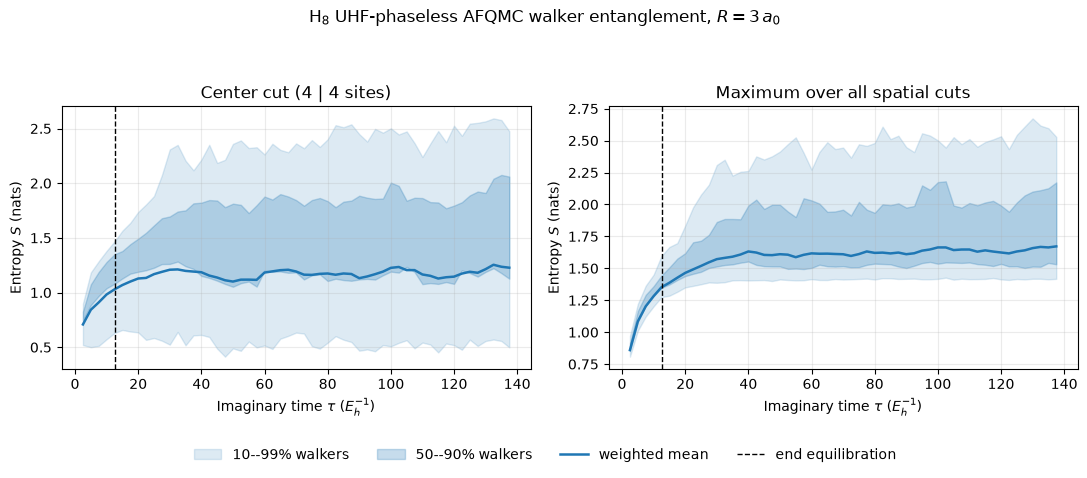

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/h8_r3_sto-6g_uhf_uw_seed731008/walker_entropy_vs_imaginary_time.pdf


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8), sharex=True)
equilibration_time = CFG.n_eql_blocks * CFG.n_prop_steps * CFG.dt

for axis, mean, quantiles, title in (
    (axes[0], center_mean, center_quantiles, "Center cut (4 | 4 sites)"),
    (axes[1], maximum_mean, maximum_quantiles, "Maximum over all spatial cuts"),
):
    axis.fill_between(
        imaginary_time,
        quantiles[:, 0],
        quantiles[:, -1],
        color="C0",
        alpha=0.15,
        label="10--99% walkers",
    )
    axis.fill_between(
        imaginary_time,
        quantiles[:, 1],
        quantiles[:, 2],
        color="C0",
        alpha=0.25,
        label="50--90% walkers",
    )
    axis.plot(imaginary_time, mean, color="C0", linewidth=1.8, label="weighted mean")
    axis.axvline(
        equilibration_time,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="end equilibration",
    )
    axis.set_title(title)
    axis.set_xlabel(r"Imaginary time $\tau$ ($E_h^{-1}$)")
    axis.set_ylabel(r"Entropy $S$ (nats)")
    axis.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    rf"H$_{{{CFG.n_h}}}$ UHF-phaseless AFQMC walker entanglement, "
    rf"$R={CFG.bond_length_bohr:g}\,a_0$",
    y=0.98,
)
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=False,
)
fig.tight_layout(rect=(0.0, 0.10, 1.0, 0.92))
figure_path = OUTPUT_DIR / "walker_entropy_vs_imaginary_time.pdf"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print("Saved", figure_path)

## Production-cut profile

The final panel shows the walker-averaged entropy at every spatial cut. For an
MPS conversion, the largest value is more relevant than assuming in advance
that the center is always the most entangled bond.


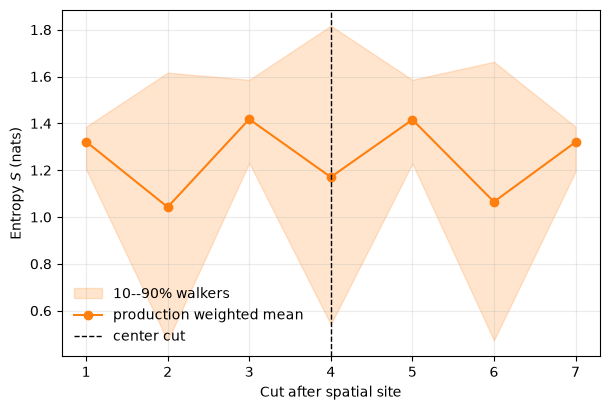

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/h8_r3_sto-6g_uhf_uw_seed731008/production_entropy_by_cut.pdf


In [ ]:
production_mask = expected_snapshot_blocks > CFG.n_eql_blocks
production_entropy_by_cut = entropy_by_cut[production_mask]
production_weights = np.abs(snapshot_weights[production_mask])

cut_means = np.empty(n_cuts)
cut_q10 = np.empty(n_cuts)
cut_q90 = np.empty(n_cuts)
for cut_index in range(n_cuts):
    values = production_entropy_by_cut[:, :, cut_index].reshape(-1)
    weights = production_weights.reshape(-1)
    cut_means[cut_index] = np.average(values, weights=weights)
    cut_q10[cut_index], cut_q90[cut_index] = weighted_quantiles(
        values, weights, np.asarray([0.10, 0.90])
    )

cuts = np.arange(1, CFG.n_h)
fig, axis = plt.subplots(figsize=(6.2, 4.2))
axis.fill_between(cuts, cut_q10, cut_q90, color="C1", alpha=0.20, label="10--90% walkers")
axis.plot(cuts, cut_means, "o-", color="C1", label="production weighted mean")
axis.axvline(center_cut, color="black", linestyle="--", linewidth=1.0, label="center cut")
axis.set_xlabel("Cut after spatial site")
axis.set_ylabel(r"Entropy $S$ (nats)")
axis.set_xticks(cuts)
axis.grid(alpha=0.25)
axis.legend(frameon=False)
fig.tight_layout()
profile_path = OUTPUT_DIR / "production_entropy_by_cut.pdf"
fig.savefig(profile_path, bbox_inches="tight")
plt.show()
print("Saved", profile_path)

# Open Hubbard-chain CPMC comparison

We now repeat the walker analysis for an eight-site, half-filled Hubbard chain
with open boundaries, nearest-neighbor hopping $t=1$, and $U/t=6$. The
Hamiltonian is

$$
H=-t\sum_{i=1}^{L-1}\sum_\sigma
\left(c^\dagger_{i\sigma}c_{i+1,\sigma}+\mathrm{h.c.}\right)
+U\sum_{i=1}^L n_{i\uparrow}n_{i\downarrow}.
$$

We calculate a broken-symmetry Hubbard-UHF reference, but use the
noninteracting half-filled determinant as the constrained-path trial. This
symmetry-adapted trial is the standard stable choice for the half-filled
bipartite chain; a local comparison found that the strongly localized UHF
determinant produced much slower, noisier importance sampling. Unrestricted
walkers are technically necessary because Trot's current fast CPMC path
represents the two spin determinants separately. The calculation uses the
same walker population, block length, timestep, equilibration, production,
and snapshot cadence as the molecular experiment.


In [ ]:
def make_open_hubbard_chain(n_sites: int, hopping: float) -> np.ndarray:
    h1 = np.zeros((n_sites, n_sites), dtype=float)
    nearest_neighbors = np.arange(n_sites - 1)
    h1[nearest_neighbors, nearest_neighbors + 1] = -hopping
    h1[nearest_neighbors + 1, nearest_neighbors] = -hopping
    return h1


def solve_hubbard_uhf(
    h1: np.ndarray,
    interaction: float,
    nelec: tuple[int, int],
    *,
    mixing: float,
    tolerance: float,
    max_cycles: int,
) -> dict[str, object]:
    """Solve collinear real-space UHF for the repulsive Hubbard model."""
    n_sites = h1.shape[0]
    n_up, n_down = nelec
    if h1.shape != (n_sites, n_sites):
        raise ValueError("h1 must be square")
    if not (0.0 < mixing <= 1.0):
        raise ValueError("mixing must lie in (0, 1]")

    # A small staggered moment selects the antiferromagnetic UHF solution.
    stagger = np.where(np.arange(n_sites) % 2 == 0, 1.0, -1.0)
    density_up = n_up / n_sites + 0.45 * stagger
    density_down = n_down / n_sites - 0.45 * stagger

    converged = False
    density_error = np.inf
    for cycle in range(1, max_cycles + 1):
        fock_up = h1 + np.diag(interaction * density_down)
        fock_down = h1 + np.diag(interaction * density_up)
        _, orbitals_up = np.linalg.eigh(fock_up)
        _, orbitals_down = np.linalg.eigh(fock_down)
        occupied_up = orbitals_up[:, :n_up]
        occupied_down = orbitals_down[:, :n_down]
        new_density_up = np.sum(np.abs(occupied_up) ** 2, axis=1)
        new_density_down = np.sum(np.abs(occupied_down) ** 2, axis=1)
        density_error = max(
            float(np.max(np.abs(new_density_up - density_up))),
            float(np.max(np.abs(new_density_down - density_down))),
        )
        density_up = (1.0 - mixing) * density_up + mixing * new_density_up
        density_down = (1.0 - mixing) * density_down + mixing * new_density_down
        if density_error < tolerance:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"Hubbard UHF did not converge in {max_cycles} cycles; "
            f"final density error={density_error:.3e}"
        )

    # Rediagonalize once at the converged density so the returned orbitals are
    # the fixed-point eigenvectors rather than the preceding iteration's.
    _, orbitals_up = np.linalg.eigh(h1 + np.diag(interaction * density_down))
    _, orbitals_down = np.linalg.eigh(h1 + np.diag(interaction * density_up))
    occupied_up = orbitals_up[:, :n_up]
    occupied_down = orbitals_down[:, :n_down]
    rdm_up = occupied_up @ occupied_up.T
    rdm_down = occupied_down @ occupied_down.T
    energy = np.einsum("ij,ji->", h1, rdm_up + rdm_down) + interaction * np.dot(
        np.diag(rdm_up), np.diag(rdm_down)
    )
    return {
        "orbitals_up": occupied_up,
        "orbitals_down": occupied_down,
        "density_up": np.diag(rdm_up),
        "density_down": np.diag(rdm_down),
        "energy": float(energy),
        "cycles": cycle,
        "density_error": float(density_error),
    }


n_hubbard_sites = CFG.n_h
if n_hubbard_sites % 2:
    raise ValueError("The half-filled comparison requires an even number of sites")
hubbard_nelec = (n_hubbard_sites // 2, n_hubbard_sites // 2)
hubbard_h1 = make_open_hubbard_chain(n_hubbard_sites, CFG.hubbard_t)
hubbard_uhf = solve_hubbard_uhf(
    hubbard_h1,
    CFG.hubbard_u,
    hubbard_nelec,
    mixing=CFG.hubbard_uhf_mixing,
    tolerance=CFG.hubbard_uhf_tol,
    max_cycles=CFG.hubbard_uhf_max_cycles,
)
hubbard_free_orbital_energies, hubbard_free_orbitals = np.linalg.eigh(hubbard_h1)
hubbard_free_occupied = hubbard_free_orbitals[:, : hubbard_nelec[0]]
hubbard_free_rdm_spin = hubbard_free_occupied @ hubbard_free_occupied.T
hubbard_free_trial_energy = 2.0 * np.einsum(
    "ij,ji->", hubbard_h1, hubbard_free_rdm_spin
) + CFG.hubbard_u * np.dot(np.diag(hubbard_free_rdm_spin), np.diag(hubbard_free_rdm_spin))

hubbard_run_tag = (
    f"hubbard_l{n_hubbard_sites}_open_u{CFG.hubbard_u:g}_" f"free_cpmc_seed{CFG.hubbard_seed}"
)
HUBBARD_OUTPUT_DIR = REPO_ROOT / "runs" / "sd_to_mps_data" / hubbard_run_tag
HUBBARD_SNAPSHOT_DIR = HUBBARD_OUTPUT_DIR / "walkers"
HUBBARD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HUBBARD_SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)

hubbard_config = {
    "n_sites": n_hubbard_sites,
    "nelec": hubbard_nelec,
    "boundary_condition": "open",
    "hopping": CFG.hubbard_t,
    "interaction": CFG.hubbard_u,
    "trial": "noninteracting_half_filled_determinant",
    "dt": CFG.dt,
    "n_walkers": CFG.n_walkers,
    "n_prop_steps": CFG.n_prop_steps,
    "n_eql_blocks": CFG.n_eql_blocks,
    "n_blocks": CFG.n_blocks,
    "snapshot_every_blocks": CFG.snapshot_every_blocks,
    "n_chunks": CFG.n_chunks,
    "seed": CFG.hubbard_seed,
    "uhf_mixing": CFG.hubbard_uhf_mixing,
    "uhf_tolerance": CFG.hubbard_uhf_tol,
    "uhf_max_cycles": CFG.hubbard_uhf_max_cycles,
}
with (HUBBARD_OUTPUT_DIR / "config.json").open("w") as handle:
    json.dump(hubbard_config, handle, indent=2)

print("Hubbard output directory:", HUBBARD_OUTPUT_DIR)
print(f"Hubbard UHF energy = {hubbard_uhf['energy']:.12f} t")
print(f"Free-electron trial energy = {hubbard_free_trial_energy:.12f} t")
print(
    f"Hubbard UHF converged in {hubbard_uhf['cycles']} cycles; "
    f"density error={hubbard_uhf['density_error']:.3e}"
)
print("UHF spin density:", hubbard_uhf["density_up"] - hubbard_uhf["density_down"])

Hubbard output directory: /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009
Hubbard UHF energy = -2.277381120333 t
Free-electron trial energy = 2.482459033713 t
Hubbard UHF converged in 43 cycles; density error=6.919e-13
UHF spin density: [ 0.94449118 -0.89082949  0.89248277 -0.89229603  0.89229603 -0.89248277
  0.89082949 -0.94449118]


## Exact reference and constrained-path propagation

For this $L=8$ system, exact diagonalization in the $(N*\uparrow,N*\downarrow)
sector is inexpensive. It provides a direct energy check on the UHF-constrained
CPMC trajectory. No exact information enters the propagation. The
broken-symmetry UHF result above is retained as a mean-field comparison; the
determinant used below is the noninteracting half-filled state.


In [ ]:
hubbard_eri = np.zeros(
    (n_hubbard_sites, n_hubbard_sites, n_hubbard_sites, n_hubbard_sites),
    dtype=float,
)
hubbard_site_indices = np.arange(n_hubbard_sites)
hubbard_eri[
    hubbard_site_indices,
    hubbard_site_indices,
    hubbard_site_indices,
    hubbard_site_indices,
] = CFG.hubbard_u
hubbard_exact_energy, _ = fci.direct_spin1.kernel(
    hubbard_h1,
    hubbard_eri,
    n_hubbard_sites,
    hubbard_nelec,
    tol=1.0e-12,
    max_cycle=300,
)
print(f"Exact ground-state energy = {hubbard_exact_energy:.12f} t")

hubbard_system = System(
    norb=n_hubbard_sites,
    nelec=hubbard_nelec,
    walker_kind="unrestricted",
)
hubbard_hamiltonian = HamHubbard(h1=jnp.asarray(hubbard_h1), u=CFG.hubbard_u)

hubbard_trial_coefficients = np.zeros((2 * n_hubbard_sites, sum(hubbard_nelec)), dtype=float)
hubbard_trial_coefficients[:n_hubbard_sites, : hubbard_nelec[0]] = hubbard_free_occupied
hubbard_trial_coefficients[n_hubbard_sites:, hubbard_nelec[0] :] = hubbard_free_occupied
hubbard_trial = GhfTrial(jnp.asarray(hubbard_trial_coefficients))
hubbard_trial_ops = make_ghf_trial_ops(hubbard_system)
hubbard_meas_ops = make_ghf_meas_ops_hubbard(hubbard_system)
hubbard_prop_ops = make_cpmc_prop_ops(
    hubbard_hamiltonian,
    hubbard_system.walker_kind,
    hubbard_trial_ops,
)

hubbard_qmc_params = QmcParams(
    dt=CFG.dt,
    n_walkers=CFG.n_walkers,
    n_prop_steps=CFG.n_prop_steps,
    n_eql_blocks=CFG.n_eql_blocks,
    n_blocks=CFG.n_blocks,
    n_chunks=CFG.n_chunks,
    seed=CFG.hubbard_seed,
    error_method="gamma",
)
hubbard_snapshot_logger = make_interval_block_state_logger(
    HUBBARD_SNAPSHOT_DIR,
    every_n_blocks=CFG.snapshot_every_blocks,
)
hubbard_result = driver.run_qmc(
    sys=hubbard_system,
    params=hubbard_qmc_params,
    ham_data=hubbard_hamiltonian,
    trial_data=hubbard_trial,
    trial_ops=hubbard_trial_ops,
    meas_ops=hubbard_meas_ops,
    prop_ops=hubbard_prop_ops,
    block_fn=hubbard_snapshot_logger,
)
print(
    f"CPMC energy = {float(hubbard_result.mean_energy):.10f} +/- "
    f"{float(hubbard_result.stderr_energy):.3e} t"
)
print(
    f"CPMC - exact = " f"{float(hubbard_result.mean_energy) - float(hubbard_exact_energy):+.6e} t"
)

hubbard_cpmc_summary = {
    "uhf_energy": float(hubbard_uhf["energy"]),
    "free_trial_energy": float(hubbard_free_trial_energy),
    "trial": "noninteracting_half_filled_determinant",
    "exact_energy": float(hubbard_exact_energy),
    "mean_energy": float(hubbard_result.mean_energy),
    "stderr_energy": float(hubbard_result.stderr_energy),
    "cpmc_minus_exact": float(hubbard_result.mean_energy - hubbard_exact_energy),
    "error_method": hubbard_result.error_method,
    "error_reliable": bool(hubbard_result.error_reliable),
    "gamma_window": hubbard_result.gamma_window,
    "gamma_window_found": bool(hubbard_result.gamma_window_found),
    "tau_int": hubbard_result.tau_int,
    "effective_sample_size": hubbard_result.effective_sample_size,
    "gamma_warnings": list(hubbard_result.gamma_warnings),
    "blocking_B_star": hubbard_result.blocking_B_star,
    "blocking_plateau_found": bool(hubbard_result.blocking_plateau_found),
    "blocking_selection_reason": hubbard_result.blocking_selection_reason,
}
with (HUBBARD_OUTPUT_DIR / "cpmc_summary.json").open("w") as handle:
    json.dump(hubbard_cpmc_summary, handle, indent=2)
np.savez_compressed(
    HUBBARD_OUTPUT_DIR / "cpmc_blocks.npz",
    energy=np.asarray(jax.device_get(hubbard_result.block_energies)),
    weight=np.asarray(jax.device_get(hubbard_result.block_weights)),
)
print("Saved", HUBBARD_OUTPUT_DIR / "cpmc_summary.json")
print("Saved", HUBBARD_OUTPUT_DIR / "cpmc_blocks.npz")
if not hubbard_result.error_reliable:
    print(
        "Energy warning: the configured error analysis is not reliable for this "
        "trajectory. Treat the reported uncertainty as diagnostic only."
    )

Exact ground-state energy = -3.103863037101 t



Equilibration:



        block           E_blk             W        nodes      t[s]


[eql    0/50]    2.4824590337  2.000000e+02           0       0.0


[eql   10/50]   -2.8276280334  2.378353e+02           0       0.7


...

  Blocking SE [diagnostic] = 6.649575e-03


  Blocking B              = 5


  Blocking selection      = plateau (plateau_found=True)


  Reported method         = gamma (reliable=yes)


CPMC energy = -3.1005745892 +/- 6.321e-03 t
CPMC - exact = +3.288448e-03 t
Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/cpmc_summary.json
Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/cpmc_blocks.npz


## Hubbard walker entanglement

The Hubbard propagator and trial are already expressed in the ordered site
basis, so the spatial transformation is the identity. As above, $\exp(S)$ is
reported only as an effective dimension; a truncation-controlled MPS bond
dimension requires the full Schmidt spectrum, not entropy alone.


In [ ]:
def analyze_unrestricted_snapshots(
    snapshot_directory: Path,
    output_directory: Path,
    *,
    snapshot_blocks: np.ndarray,
    n_walkers: int,
    n_sites: int,
    basis_to_local: np.ndarray,
    n_prop_steps: int,
    dt: float,
    n_eql_blocks: int,
) -> dict[str, object]:
    snapshot_paths = [
        snapshot_directory / f"block_state_{block_number:05d}.npz"
        for block_number in snapshot_blocks
    ]
    missing = [path for path in snapshot_paths if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Missing expected walker snapshots: {missing}")

    center = n_sites // 2
    n_snapshot = len(snapshot_paths)
    entropies = np.empty((n_snapshot, n_walkers, n_sites - 1), dtype=float)
    weights_all = np.empty((n_snapshot, n_walkers), dtype=float)
    nu_up_center = np.empty((n_snapshot, n_walkers, center), dtype=float)
    nu_down_center = np.empty((n_snapshot, n_walkers, center), dtype=float)

    for snapshot_index, path in enumerate(snapshot_paths):
        state = load_prop_state_npz(path)
        walkers_up, walkers_down = jax.device_get(state.walkers)
        weights = np.asarray(jax.device_get(state.weights), dtype=float)
        weights_all[snapshot_index] = weights
        for walker_index, (walker_up, walker_down) in enumerate(
            zip(np.asarray(walkers_up), np.asarray(walkers_down), strict=True)
        ):
            profile, spectra = walker_entropy_profile(
                walker_up,
                walker_down,
                basis_to_local,
            )
            entropies[snapshot_index, walker_index] = profile
            nu_up, nu_down = spectra[center - 1]
            nu_up_center[snapshot_index, walker_index] = nu_up
            nu_down_center[snapshot_index, walker_index] = nu_down

    center_values = entropies[:, :, center - 1]
    maximum_values = np.max(entropies, axis=-1)
    probabilities = np.asarray([0.10, 0.50, 0.90, 0.95, 0.99])
    center_average = np.empty(n_snapshot)
    center_q = np.empty((n_snapshot, len(probabilities)))
    maximum_average = np.empty(n_snapshot)
    maximum_q = np.empty((n_snapshot, len(probabilities)))
    for snapshot_index in range(n_snapshot):
        weights = np.abs(weights_all[snapshot_index])
        center_average[snapshot_index] = np.average(center_values[snapshot_index], weights=weights)
        maximum_average[snapshot_index] = np.average(
            maximum_values[snapshot_index], weights=weights
        )
        center_q[snapshot_index] = weighted_quantiles(
            center_values[snapshot_index], weights, probabilities
        )
        maximum_q[snapshot_index] = weighted_quantiles(
            maximum_values[snapshot_index], weights, probabilities
        )

    times = snapshot_blocks * n_prop_steps * dt
    np.savez_compressed(
        output_directory / "walker_entanglement.npz",
        block=snapshot_blocks,
        imaginary_time=times,
        entropy_by_cut=entropies,
        center_entropy=center_values,
        maximum_entropy=maximum_values,
        snapshot_weights=weights_all,
        center_nu_alpha=nu_up_center,
        center_nu_beta=nu_down_center,
        quantile_probabilities=probabilities,
        center_mean=center_average,
        center_quantiles=center_q,
        maximum_mean=maximum_average,
        maximum_quantiles=maximum_q,
    )

    rows = []
    for index, block_number in enumerate(snapshot_blocks):
        row = {
            "block": int(block_number),
            "phase": "equilibration" if block_number <= n_eql_blocks else "production",
            "imaginary_time": float(times[index]),
            "center_mean_entropy": float(center_average[index]),
            "center_effective_dimension": float(np.exp(center_average[index])),
            "maximum_mean_entropy": float(maximum_average[index]),
            "maximum_effective_dimension": float(np.exp(maximum_average[index])),
        }
        for probability, value in zip(probabilities, center_q[index], strict=True):
            row[f"center_q{int(round(100 * probability)):02d}"] = float(value)
        for probability, value in zip(probabilities, maximum_q[index], strict=True):
            row[f"maximum_q{int(round(100 * probability)):02d}"] = float(value)
        rows.append(row)

    with (output_directory / "entropy_summary.csv").open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    return {
        "entropy_by_cut": entropies,
        "weights": weights_all,
        "center_entropy": center_values,
        "maximum_entropy": maximum_values,
        "probabilities": probabilities,
        "center_mean": center_average,
        "center_quantiles": center_q,
        "maximum_mean": maximum_average,
        "maximum_quantiles": maximum_q,
        "imaginary_time": times,
        "summary_rows": rows,
    }


hubbard_entropy = analyze_unrestricted_snapshots(
    HUBBARD_SNAPSHOT_DIR,
    HUBBARD_OUTPUT_DIR,
    snapshot_blocks=expected_snapshot_blocks,
    n_walkers=CFG.n_walkers,
    n_sites=n_hubbard_sites,
    basis_to_local=np.eye(n_hubbard_sites),
    n_prop_steps=CFG.n_prop_steps,
    dt=CFG.dt,
    n_eql_blocks=CFG.n_eql_blocks,
)
print("Saved", HUBBARD_OUTPUT_DIR / "walker_entanglement.npz")
print("Saved", HUBBARD_OUTPUT_DIR / "entropy_summary.csv")
print("Final Hubbard snapshot summary:")
for key, value in hubbard_entropy["summary_rows"][-1].items():
    print(f"  {key:>30s}: {value}")

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/walker_entanglement.npz
Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/entropy_summary.csv
Final Hubbard snapshot summary:
                           block: 550
                           phase: production
                  imaginary_time: 137.5
             center_mean_entropy: 0.2530832931436618
      center_effective_dimension: 1.287990553149056
            maximum_mean_entropy: 0.884096231081609
     maximum_effective_dimension: 2.420795562749454
                      center_q10: 0.008703311273613235
                      center_q50: 0.0914177928350659
                      center_q90: 0.7030954227159697
                      center_q95: 1.207955161207695
                      center_q99: 1.3610837187483973
                     maximum_q10: 0.26866592359297786
                     maximum_q50: 0.9953472110241423
                     maximu

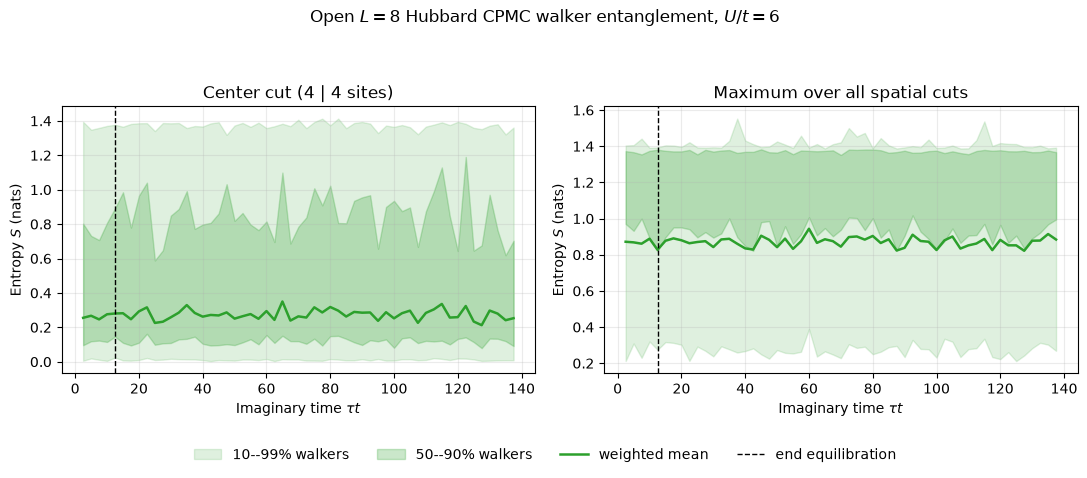

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/walker_entropy_vs_imaginary_time.pdf


In [ ]:
hubbard_time = hubbard_entropy["imaginary_time"]
hubbard_center_mean = hubbard_entropy["center_mean"]
hubbard_center_quantiles = hubbard_entropy["center_quantiles"]
hubbard_maximum_mean = hubbard_entropy["maximum_mean"]
hubbard_maximum_quantiles = hubbard_entropy["maximum_quantiles"]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8), sharex=True)
for axis, mean, quantiles, title in (
    (
        axes[0],
        hubbard_center_mean,
        hubbard_center_quantiles,
        "Center cut (4 | 4 sites)",
    ),
    (
        axes[1],
        hubbard_maximum_mean,
        hubbard_maximum_quantiles,
        "Maximum over all spatial cuts",
    ),
):
    axis.fill_between(
        hubbard_time,
        quantiles[:, 0],
        quantiles[:, -1],
        color="C2",
        alpha=0.15,
        label="10--99% walkers",
    )
    axis.fill_between(
        hubbard_time,
        quantiles[:, 1],
        quantiles[:, 2],
        color="C2",
        alpha=0.25,
        label="50--90% walkers",
    )
    axis.plot(hubbard_time, mean, color="C2", linewidth=1.8, label="weighted mean")
    axis.axvline(
        equilibration_time,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="end equilibration",
    )
    axis.set_title(title)
    axis.set_xlabel(r"Imaginary time $\tau t$")
    axis.set_ylabel(r"Entropy $S$ (nats)")
    axis.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    rf"Open $L={n_hubbard_sites}$ Hubbard CPMC walker entanglement, "
    rf"$U/t={CFG.hubbard_u / CFG.hubbard_t:g}$",
    y=0.98,
)
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=False,
)
fig.tight_layout(rect=(0.0, 0.10, 1.0, 0.92))
hubbard_time_figure = HUBBARD_OUTPUT_DIR / "walker_entropy_vs_imaginary_time.pdf"
fig.savefig(hubbard_time_figure, bbox_inches="tight")
plt.show()
print("Saved", hubbard_time_figure)

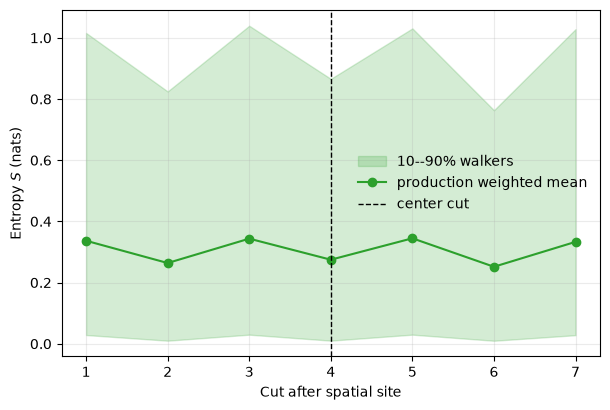

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/production_entropy_by_cut.pdf


In [ ]:
hubbard_production_mask = expected_snapshot_blocks > CFG.n_eql_blocks
hubbard_production_entropies = hubbard_entropy["entropy_by_cut"][hubbard_production_mask]
hubbard_production_weights = np.abs(hubbard_entropy["weights"][hubbard_production_mask])
hubbard_cut_means = np.empty(n_cuts)
hubbard_cut_q10 = np.empty(n_cuts)
hubbard_cut_q90 = np.empty(n_cuts)
for cut_index in range(n_cuts):
    values = hubbard_production_entropies[:, :, cut_index].reshape(-1)
    weights = hubbard_production_weights.reshape(-1)
    hubbard_cut_means[cut_index] = np.average(values, weights=weights)
    hubbard_cut_q10[cut_index], hubbard_cut_q90[cut_index] = weighted_quantiles(
        values,
        weights,
        np.asarray([0.10, 0.90]),
    )

fig, axis = plt.subplots(figsize=(6.2, 4.2))
axis.fill_between(
    cuts,
    hubbard_cut_q10,
    hubbard_cut_q90,
    color="C2",
    alpha=0.20,
    label="10--90% walkers",
)
axis.plot(
    cuts,
    hubbard_cut_means,
    "o-",
    color="C2",
    label="production weighted mean",
)
axis.axvline(center_cut, color="black", linestyle="--", linewidth=1.0, label="center cut")
axis.set_xlabel("Cut after spatial site")
axis.set_ylabel(r"Entropy $S$ (nats)")
axis.set_xticks(cuts)
axis.grid(alpha=0.25)
axis.legend(frameon=False)
fig.tight_layout()
hubbard_profile_path = HUBBARD_OUTPUT_DIR / "production_entropy_by_cut.pdf"
fig.savefig(hubbard_profile_path, bbox_inches="tight")
plt.show()
print("Saved", hubbard_profile_path)

## Molecular/Hubbard comparison

The projection-time axes use each Hamiltonian's native energy unit and should
not be interpreted as a direct physical time comparison. The useful comparison
is the scale and distribution of walker entanglement at equal algorithmic
settings.


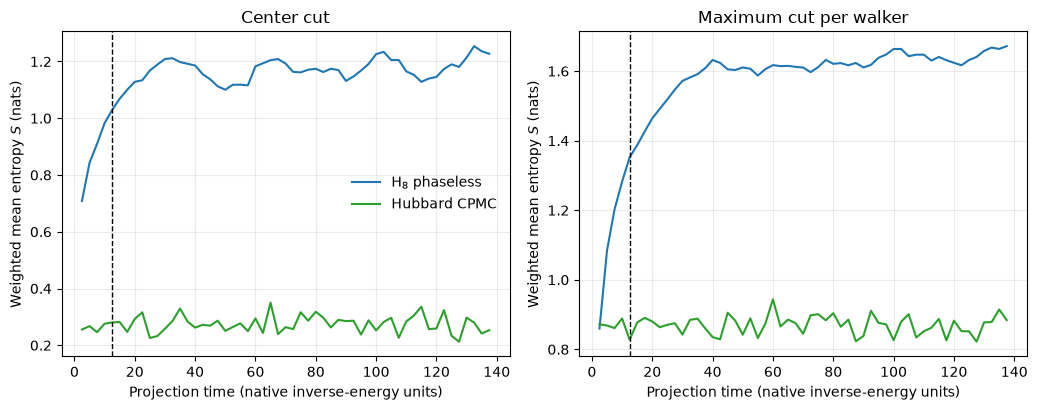

Saved /Users/amahajan/software/trot/runs/sd_to_mps_data/hubbard_l8_open_u6_free_cpmc_seed731009/h8_molecule_hubbard_entropy_comparison.pdf


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharex=True)
for axis, molecular_values, hubbard_values, title in (
    (axes[0], center_mean, hubbard_center_mean, "Center cut"),
    (axes[1], maximum_mean, hubbard_maximum_mean, "Maximum cut per walker"),
):
    axis.plot(imaginary_time, molecular_values, color="C0", label=r"H$_8$ phaseless")
    axis.plot(hubbard_time, hubbard_values, color="C2", label="Hubbard CPMC")
    axis.axvline(equilibration_time, color="black", linestyle="--", linewidth=1.0)
    axis.set_title(title)
    axis.set_xlabel(r"Projection time (native inverse-energy units)")
    axis.set_ylabel(r"Weighted mean entropy $S$ (nats)")
    axis.grid(alpha=0.25)
axes[0].legend(frameon=False)
fig.tight_layout()
comparison_path = HUBBARD_OUTPUT_DIR / "h8_molecule_hubbard_entropy_comparison.pdf"
fig.savefig(comparison_path, bbox_inches="tight")
plt.show()
print("Saved", comparison_path)

In [ ]:
import numpy as np

from trot import config

config.configure_once()

import jax.numpy as jnp
from pyscf import fci

from trot import driver
from trot.core.system import System
from trot.ham.hubbard import HamHubbard
from trot.meas.ghf import make_ghf_meas_ops_hubbard
from trot.prop.cpmc import make_prop_ops as make_cpmc_prop_ops
from trot.prop.blocks import block
from trot.prop.types import QmcParams
from trot.trial.ghf import GhfTrial, make_ghf_trial_ops

n_sites = 8
n_elec = (n_sites // 2, n_sites // 2)
u = 6.0
h1 = np.zeros((n_sites, n_sites), dtype=float)
eri = np.zeros((n_sites, n_sites, n_sites, n_sites), dtype=float)
periodic = 0
for i in range(n_sites):
    h1[i, (i + 1) % n_sites] = -1.0 + (1 - periodic) * (i == n_sites - 1)
    h1[(i + 1) % n_sites, i] = -1.0 + (1 - periodic) * (i == n_sites - 1)
    eri[i, i, i, i] = u
_, hubbard_free = np.linalg.eigh(h1)
hubbard_free_occupied = hubbard_free[:, : n_elec[0]]

hubbard_exact_energy, _ = fci.direct_spin1.kernel(h1, eri, n_sites, n_elec)
print(f"Exact ground-state energy = {hubbard_exact_energy:.12f} t")

hubbard_system = System(
    norb=n_sites,
    nelec=n_elec,
    walker_kind="unrestricted",
)
hubbard_hamiltonian = HamHubbard(h1=jnp.asarray(h1), u=u)

hubbard_trial_coefficients = np.zeros((2 * n_sites, sum(n_elec)), dtype=float)
hubbard_trial_coefficients[:n_sites, : n_elec[0]] = hubbard_free_occupied
hubbard_trial_coefficients[n_sites:, n_elec[0] :] = hubbard_free_occupied
hubbard_trial = GhfTrial(jnp.asarray(hubbard_trial_coefficients))
hubbard_trial_ops = make_ghf_trial_ops(hubbard_system)
hubbard_meas_ops = make_ghf_meas_ops_hubbard(hubbard_system)
hubbard_prop_ops = make_cpmc_prop_ops(
    hubbard_hamiltonian,
    hubbard_system.walker_kind,
    hubbard_trial_ops,
)

hubbard_qmc_params = QmcParams(
    dt=0.005,
    n_walkers=200,
    n_prop_steps=50,
    n_eql_blocks=100,
    n_blocks=1000,
    seed=352,
    error_method="gamma",
)

hubbard_result = driver.run_qmc(
    sys=hubbard_system,
    params=hubbard_qmc_params,
    ham_data=hubbard_hamiltonian,
    trial_data=hubbard_trial,
    trial_ops=hubbard_trial_ops,
    meas_ops=hubbard_meas_ops,
    prop_ops=hubbard_prop_ops,
    block_fn=block,
)

Exact ground-state energy = -3.103863031233 t

Equilibration:

        block           E_blk             W        nodes      t[s]
[eql    0/100]    2.4824590337  2.000000e+02           0       0.0
[eql   20/100]   -3.0284659484  2.262644e+02           0       1.2
[eql   40/100]   -3.1658958320  2.033394e+02           0       2.2
[eql   60/100]   -3.0641154519  2.001117e+02           0       2.9
[eql   80/100]   -3.1280210745  2.003301e+02           0       3.6
[eql  100/100]   -3.0783944765  1.994782e+02           0       4.3

Sampling:

        block           E_avg       E_err         E_block             W         nodes    dt[s/bl]     t[s]
[blk  100/1000]   -3.0987814224   1.324e-02     -3.0987814224  2.001166e+02           0      0.038       8.1
[blk  200/1000]   -3.0936669968   1.090e-02     -3.0885469690  1.998976e+02           0      0.034      11.4
[blk  300/1000]   -3.0929655596   9.585e-03     -3.0915624790  1.999777e+02           0      0.034      14.8
[blk  400/1000]   -3.0